# Pipeline Analysis
**Project 2 — Revenue & GTM Analytics**

Analyzes the current open pipeline for health, risk, and forecast accuracy.

**Key questions:**
1. What is the total pipeline value and weighted pipeline forecast?
2. How much pipeline is past due, stale, or repeatedly slipped?
3. Which segments / regions have the healthiest pipeline?
4. How does pipeline risk correlate with deal size and age?

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from mart_simulator import build_fct_pipeline, build_stg_opps

pd.set_option('display.float_format', '{:,.1f}'.format)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
pipeline = build_fct_pipeline()
all_opps = build_stg_opps()

print(f'Open opportunities: {len(pipeline):,}')
print(f'Total pipeline:     ${pipeline["pipeline_amount"].sum():,.0f}')
print(f'Weighted pipeline:  ${pipeline["weighted_pipeline_amount"].sum():,.0f}')
print(f'Snapshot date:      {pipeline["snapshot_date"].iloc[0]}')

Open opportunities: 1,142
Total pipeline:     $32,844,814
Weighted pipeline:  $9,789,762
Snapshot date:      2026-09-09 00:00:00


## 2. Pipeline Overview by Stage

In [3]:
stage_summary = (
    pipeline.groupby(['opportunity_stage', 'stage_order'])
    .agg(
        deal_count=('opportunity_id', 'nunique'),
        total_pipeline=('pipeline_amount', 'sum'),
        weighted_pipeline=('weighted_pipeline_amount', 'sum'),
        avg_deal_size=('pipeline_amount', 'mean'),
        avg_days_open=('days_open', 'mean'),
        win_rate=('stage_win_rate', 'mean'),
    )
    .reset_index()
    .sort_values('stage_order')
)

display(stage_summary[['opportunity_stage','deal_count','total_pipeline','weighted_pipeline','avg_deal_size','avg_days_open','win_rate']]
    .style
    .format({
        'deal_count': '{:,}',
        'total_pipeline': '${:,.0f}',
        'weighted_pipeline': '${:,.0f}',
        'avg_deal_size': '${:,.0f}',
        'avg_days_open': '{:.0f}d',
        'win_rate': '{:.0%}'
    })
    .background_gradient(subset=['total_pipeline'], cmap='Blues')
)

,opportunity_stage,deal_count,total_pipeline,weighted_pipeline,avg_deal_size,avg_days_open,win_rate
2,Prospecting,257,"$7,259,777","$362,989","$28,248",656d,5%
3,Qualification,327,"$8,721,715","$1,308,257","$26,672",655d,15%
1,Proposal,322,"$9,475,478","$3,316,417","$29,427",644d,35%
0,Negotiation,236,"$7,387,844","$4,802,099","$31,304",642d,65%


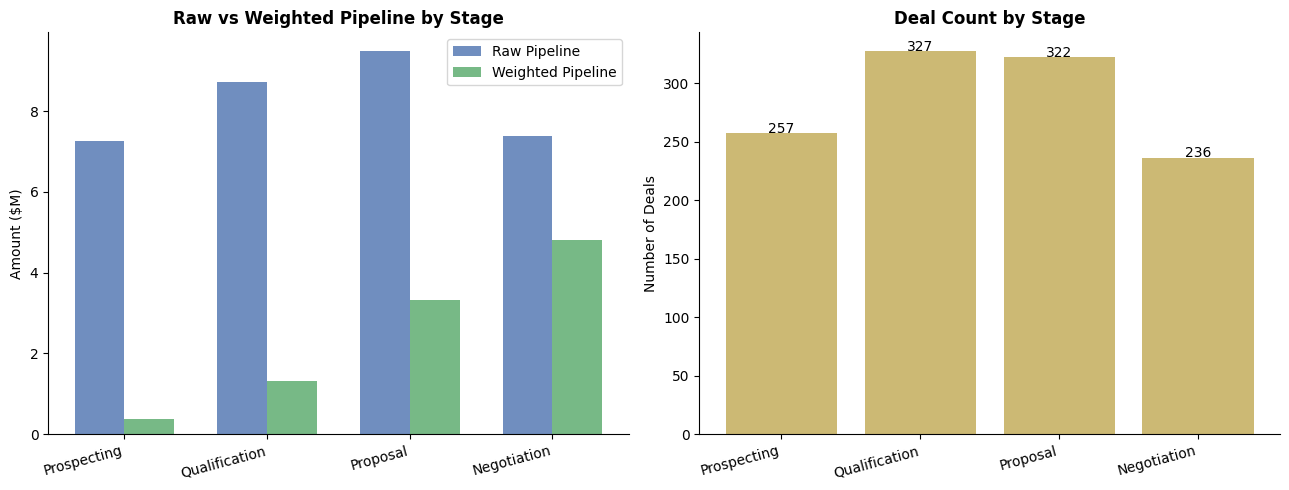

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stages = stage_summary['opportunity_stage']
x = range(len(stages))

# Left: raw vs weighted pipeline by stage
w = 0.35
axes[0].bar([i - w/2 for i in x], stage_summary['total_pipeline']/1e6, w,
            label='Raw Pipeline', color='#4C72B0', alpha=0.8)
axes[0].bar([i + w/2 for i in x], stage_summary['weighted_pipeline']/1e6, w,
            label='Weighted Pipeline', color='#55A868', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(stages, rotation=15, ha='right')
axes[0].set_ylabel('Amount ($M)')
axes[0].set_title('Raw vs Weighted Pipeline by Stage', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: deal count by stage
axes[1].bar(stages, stage_summary['deal_count'], color='#CCB974')
for i, (s, n) in enumerate(zip(stages, stage_summary['deal_count'])):
    axes[1].text(i, n + 0.5, str(n), ha='center', fontsize=10)
axes[1].set_xticklabels(stages, rotation=15, ha='right')
axes[1].set_xticks(list(range(len(stages))))
axes[1].set_ylabel('Number of Deals')
axes[1].set_title('Deal Count by Stage', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Pipeline Risk Analysis

Three risk signals from `stg_salesforce_opportunities`:
- `is_past_due` — close date has passed
- `is_stale` — no activity in 30+ days
- `has_repeated_slip` — close date changed ≥2 times

In [5]:
risk_summary = pipeline.groupby('pipeline_risk').agg(
    deal_count=('opportunity_id', 'nunique'),
    total_pipeline=('pipeline_amount', 'sum'),
    avg_deal_size=('pipeline_amount', 'mean'),
    avg_days_open=('days_open', 'mean'),
    avg_days_past_due=('days_past_due', 'mean'),
).reset_index()
risk_summary['pct_pipeline'] = risk_summary['total_pipeline'] / risk_summary['total_pipeline'].sum()

print('=== Pipeline Risk Breakdown ===')
display(risk_summary.style.format({
    'deal_count': '{:,}',
    'total_pipeline': '${:,.0f}',
    'avg_deal_size': '${:,.0f}',
    'avg_days_open': '{:.0f}d',
    'avg_days_past_due': '{:.0f}d',
    'pct_pipeline': '{:.1%}'
}).background_gradient(subset=['pct_pipeline'], cmap='Reds'))

=== Pipeline Risk Breakdown ===


,pipeline_risk,deal_count,total_pipeline,avg_deal_size,avg_days_open,avg_days_past_due,pct_pipeline
0,High Risk,136,"$3,987,279","$29,318",657d,572d,12.1%
1,Medium Risk,"1,006","$28,857,536","$28,685",648d,565d,87.9%


In [6]:
# Risk flag individual breakdown
past_due_count  = pipeline['is_past_due'].sum()
past_due_val    = pipeline.loc[pipeline['is_past_due'], 'pipeline_amount'].sum()
stale_count     = pipeline['is_stale'].sum()
stale_val       = pipeline.loc[pipeline['is_stale'], 'pipeline_amount'].sum()
slip_count      = pipeline['has_repeated_slip'].sum()
slip_val        = pipeline.loc[pipeline['has_repeated_slip'], 'pipeline_amount'].sum()

total_pipe      = pipeline['pipeline_amount'].sum()
total_deals     = len(pipeline)

flags = pd.DataFrame({
    'Risk Signal': ['Past Due (close date passed)', 'Stale (no activity 30d+)', 'Repeated Slip (≥2 changes)'],
    'Deals': [past_due_count, stale_count, slip_count],
    '% of Open Deals': [past_due_count/total_deals, stale_count/total_deals, slip_count/total_deals],
    'Pipeline at Risk': [past_due_val, stale_val, slip_val],
    '% of Pipeline': [past_due_val/total_pipe, stale_val/total_pipe, slip_val/total_pipe],
})
display(flags.style.format({
    'Deals': '{:,}',
    '% of Open Deals': '{:.1%}',
    'Pipeline at Risk': '${:,.0f}',
    '% of Pipeline': '{:.1%}'
}).background_gradient(subset=['% of Pipeline'], cmap='Oranges'))

,Risk Signal,Deals,% of Open Deals,Pipeline at Risk,% of Pipeline
0,Past Due (close date passed),"1,142",100.0%,"$32,844,814",100.0%
1,Stale (no activity 30d+),"1,142",100.0%,"$32,844,814",100.0%
2,Repeated Slip (≥2 changes),136,11.9%,"$3,987,279",12.1%


## 4. Pipeline by Segment and Region

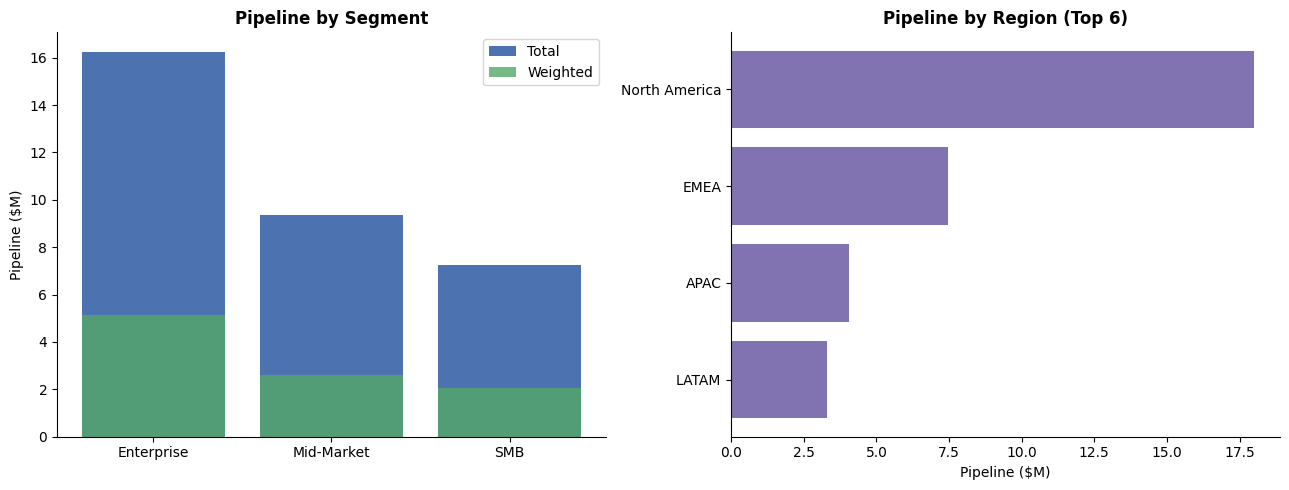


Segment summary:


,segment,deals,total_pipeline,weighted_pipeline,at_risk_count,avg_deal,risk_rate
0,Enterprise,210,"$16,255,604","$5,151,719",27,"$77,408",12.9%
1,Mid-Market,375,"$9,358,301","$2,600,202",44,"$24,955",11.7%
2,SMB,557,"$7,230,910","$2,037,841",65,"$12,982",11.7%


In [7]:
seg_pipe = pipeline.groupby('segment').agg(
    deals=('opportunity_id', 'nunique'),
    total_pipeline=('pipeline_amount', 'sum'),
    weighted_pipeline=('weighted_pipeline_amount', 'sum'),
    at_risk_count=('pipeline_risk', lambda x: (x == 'High Risk').sum()),
).reset_index().sort_values('total_pipeline', ascending=False)

seg_pipe['avg_deal'] = seg_pipe['total_pipeline'] / seg_pipe['deals']
seg_pipe['risk_rate'] = seg_pipe['at_risk_count'] / seg_pipe['deals']

region_pipe = pipeline.groupby('region').agg(
    deals=('opportunity_id', 'nunique'),
    total_pipeline=('pipeline_amount', 'sum'),
    weighted_pipeline=('weighted_pipeline_amount', 'sum'),
).reset_index().sort_values('total_pipeline', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By segment
axes[0].bar(seg_pipe['segment'], seg_pipe['total_pipeline']/1e6, color='#4C72B0', label='Total')
axes[0].bar(seg_pipe['segment'], seg_pipe['weighted_pipeline']/1e6, color='#55A868', alpha=0.8, label='Weighted')
axes[0].set_ylabel('Pipeline ($M)')
axes[0].set_title('Pipeline by Segment', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# By region
top_regions = region_pipe.head(6)
axes[1].barh(top_regions['region'][::-1], top_regions['total_pipeline'][::-1]/1e6, color='#8172B2')
axes[1].set_xlabel('Pipeline ($M)')
axes[1].set_title('Pipeline by Region (Top 6)', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSegment summary:')
display(seg_pipe.style.format({
    'deals': '{:,}',
    'total_pipeline': '${:,.0f}',
    'weighted_pipeline': '${:,.0f}',
    'avg_deal': '${:,.0f}',
    'risk_rate': '{:.1%}'
}))

## 5. Deal Age Distribution — Identifying Zombie Deals

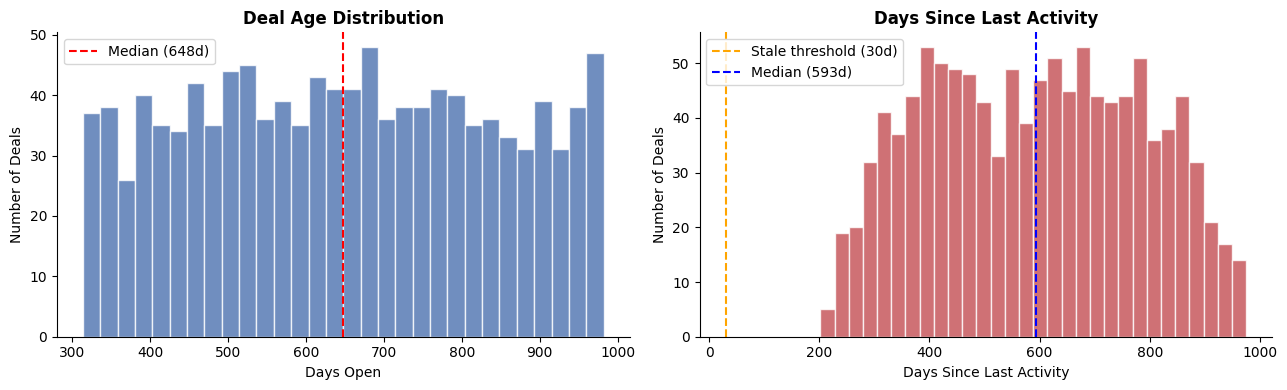

Deals with no activity in 90+ days: 1,142 ($32,844,814)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(pipeline['days_open'].dropna(), bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(pipeline['days_open'].median(), color='red', linestyle='--', label=f'Median ({pipeline["days_open"].median():.0f}d)')
axes[0].set_xlabel('Days Open')
axes[0].set_ylabel('Number of Deals')
axes[0].set_title('Deal Age Distribution', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(pipeline['days_since_last_activity'].dropna(), bins=30, color='#C44E52', edgecolor='white', alpha=0.8)
axes[1].axvline(30, color='orange', linestyle='--', label='Stale threshold (30d)')
axes[1].axvline(pipeline['days_since_last_activity'].median(), color='blue', linestyle='--',
                label=f'Median ({pipeline["days_since_last_activity"].median():.0f}d)')
axes[1].set_xlabel('Days Since Last Activity')
axes[1].set_ylabel('Number of Deals')
axes[1].set_title('Days Since Last Activity', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

zombie_threshold = 90
zombie_deals = pipeline[pipeline['days_since_last_activity'] > zombie_threshold]
print(f'Deals with no activity in {zombie_threshold}+ days: {len(zombie_deals):,} (${zombie_deals["pipeline_amount"].sum():,.0f})')

## 6. Summary — Key Findings

In [9]:
high_risk_val  = pipeline.loc[pipeline['pipeline_risk']=='High Risk', 'pipeline_amount'].sum()
med_risk_val   = pipeline.loc[pipeline['pipeline_risk']=='Medium Risk', 'pipeline_amount'].sum()
on_track_val   = pipeline.loc[pipeline['pipeline_risk']=='On Track', 'pipeline_amount'].sum()
weighted_total = pipeline['weighted_pipeline_amount'].sum()

print('=' * 58)
print('  PIPELINE ANALYSIS — KEY FINDINGS')
print('=' * 58)
print(f'  Open deals:            {len(pipeline):,}')
print(f'  Total raw pipeline:    ${total_pipe:,.0f}')
print(f'  Weighted pipeline:     ${weighted_total:,.0f} ({weighted_total/total_pipe:.0%} of raw)')
print(f'  High Risk deals:       ${high_risk_val:,.0f} ({high_risk_val/total_pipe:.1%} of pipeline)')
print(f'  Medium Risk deals:     ${med_risk_val:,.0f} ({med_risk_val/total_pipe:.1%} of pipeline)')
print(f'  On Track:              ${on_track_val:,.0f} ({on_track_val/total_pipe:.1%} of pipeline)')
print(f'  Past due:              {past_due_count} deals (${past_due_val:,.0f})')
print(f'  Stale (30d+):          {stale_count} deals (${stale_val:,.0f})')
print(f'  Repeated slippage:     {slip_count} deals (${slip_val:,.0f})')
print('=' * 58)
print('\ndbt model: fct_pipeline')

  PIPELINE ANALYSIS — KEY FINDINGS
  Open deals:            1,142
  Total raw pipeline:    $32,844,814
  Weighted pipeline:     $9,789,762 (30% of raw)
  High Risk deals:       $3,987,279 (12.1% of pipeline)
  Medium Risk deals:     $28,857,536 (87.9% of pipeline)
  On Track:              $0 (0.0% of pipeline)
  Past due:              1142 deals ($32,844,814)
  Stale (30d+):          1142 deals ($32,844,814)
  Repeated slippage:     136 deals ($3,987,279)

dbt model: fct_pipeline
